# Часть 1. Исследование многомерного нормального распределения

### 1.1 Генерация данных с заданной ковариацией
**Цель:** научиться генерировать данные с контролируемой структурой зависимости.

1. Создайте $ M = 500 $ точек в двумерном пространстве:
   - Сгенерируйте два независимых вектора: $ x_1 \sim \mathcal{N}(0, \sigma_1^2) $, $ x_2 \sim \mathcal{N}(0, \sigma_2^2) $, где $ \sigma_1 = 0.3 $, $ \sigma_2 = 0.8 $.
2. Примените матрицу поворота на угол $ \alpha = 30^\circ $:
   $
   R = \begin{bmatrix} \cos\alpha & -\sin\alpha \\ \sin\alpha & \cos\alpha \end{bmatrix}
   $
3. Выведите на экран **выборочную матрицу ковариации** (через `np.cov`).
4. Сравните с теоретической: $ C_{теор} = R \cdot \text{diag}(\sigma_1^2, \sigma_2^2) \cdot R^T $.

**Визуализация:**
- Постройте scatter plot полученных точек.
- На том же графике (используя `plt.contour`) нарисуйте эллипсы равной плотности для теоретического распределения (на уровнях 0.5, 1, 2 стандартных отклонения).

**Автопроверка:**
```python
# Проверка: размерность и наличие поворота
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"
```

### 1.2 Сравнение с встроенной функцией
- Сгенерируйте точки с помощью `np.random.multivariate_normal` с той же матрицей ковариации.
- Нарисуйте оба облака точек на одном графике разными цветами.
- **Вопрос (ответить текстом в Markdown):** совпадают ли облака визуально? Почему встроенная функция может быть предпочтительнее?


[[ 0.23741448 -0.25302313]
 [-0.25302313  0.51473488]] [[ 0.2275     -0.23815699]
 [-0.23815699  0.5025    ]]


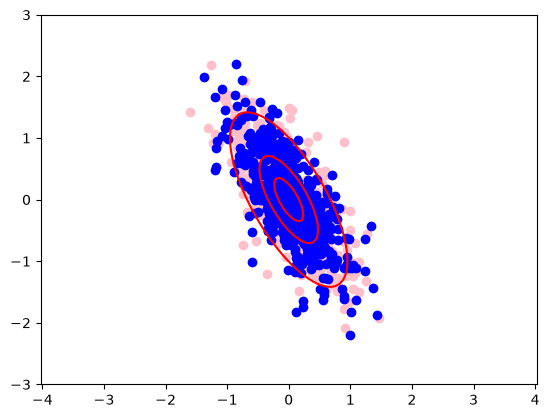

In [84]:
import numpy as np

import matplotlib.pyplot as plt

M = 500

# creating the random vecors from 500 random points centered around 0 and sitting tightly at 0.3 and 0.8
x1 = np.random.normal(0, 0.3, M)
x2 = np.random.normal(0, 0.8, M)

# stacking the vectors together 
XV = np.vstack([x1, x2])

a = np.pi / 6

R = np.array([[np.cos(a), -np.sin(a)], 
              [np.sin(a), np.cos(a)]])

# multiplying the matrixes
Y = R @ XV

X = Y.T

Y_check =  np.random.multivariate_normal([0, 0],C_tr, M).T

# finding the covariance matrix
C = np.cov(Y)

C_tr = R @ np.diag([0.3**2, 0.8**2])@R.T
print(C, C_tr)

# visualising!! YAYYY

plt.scatter(Y[0, :], Y[1, :], c = 'pink')
plt.scatter(Y_check[0, :], Y_check[1, :], c = 'blue')
plt.axis('equal')
grid_range = np.linspace(-3, 3, 100)
X_grid, Y_grid = np.meshgrid(grid_range, grid_range)

C_inv = np.linalg.inv(C_tr)
#finding the distance from the men to the said point 
Z = (C_inv[0, 0] * X_grid**2 + 
     (C_inv[0, 1] + C_inv[1, 0]) * X_grid * Y_grid + 
     C_inv[1, 1] * Y_grid**2)

plt.contour(X_grid, Y_grid, Z, levels=[0.5**2, 1.0**2, 2.0**2], colors='red')


plt.show()

# Проверка: размерность и наличие поворота
assert X.shape == (M, 2), "Неверная размерность данных"
assert np.abs(np.cov(X.T)[0, 1]) > 0.1, "Корреляция слишком мала (проверьте поворот)"
assert np.allclose(np.mean(X, axis=0), 0, atol=0.1), "Среднее должно быть около 0"


**Ответ:** В центре голубыл и розовые точки совпадалют. Встроенная функция может быть предпочтительнее потому что вместо 7 сторк кода, нужно написать только одно: np.random.multivariate_normal()

## Часть 2. Визуализация плотности вероятности (5 баллов)

**Цель:** научиться вычислять и визуализировать PDF многомерного нормального распределения.

1. По данным из пункта 1.1 оцените $ \hat{\mu} $ и $ \hat{C} $ (выборочные).
2. Создайте сетку точек в диапазоне от -2 до 2 по обеим осям.
3. Вычислите плотность вероятности в каждой точке сетки **двумя способами**:
   - С помощью `scipy.stats.multivariate_normal(mean=mu, cov=C).pdf()`.
   - Самостоятельно по формуле (1) из задания (используйте `np.linalg.det` и `np.linalg.inv`).
4. Сравните результаты (максимальная разница должна быть < 1e-10).

**Визуализация:**
- Постройте contour plot с заливкой (используя `plt.contourf`).
- Добавьте линии уровня (contour) с подписями значений.
- Нанесите исходные точки поверх фона.

**Автопроверка:**
```python
# Проверка ручного вычисления
pdf_manual = ... # ваша реализация
pdf_scipy = m.pdf(grid_points)
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"
```


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


yes


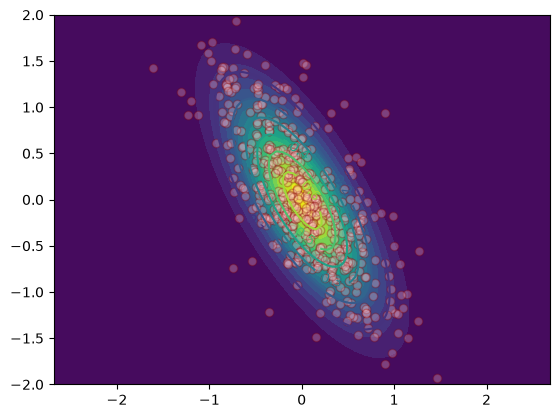

In [96]:
import scipy


mu_hat = np.mean(Y, axis=1)

C_hat = np.cov(Y)

X_grid_new, Y_grid_new = np.meshgrid(grid_range, grid_range)
pos = np.dstack((X_grid_new, Y_grid_new))
C_hat_inv = np.linalg.inv(C_hat)



# Method 1
den = scipy.stats.multivariate_normal(mean=mu_hat, cov=C_hat).pdf(pos)

#Method 2

Z_new = (C_hat_inv[0, 0] * X_grid_new**2 + 
     (C_hat_inv[0, 1] + C_inv[1, 0]) * X_grid_new * Y_grid_new + 
     C_hat_inv[1, 1] * Y_grid_new**2)

coef = 1 / (2*np.pi * np.sqrt(np.linalg.det(C_hat)))
func = coef * np.exp(-1/2*Z_new)

# Comparison
coef1 = 1 / (2*np.pi * np.sqrt(np.linalg.det(C_hat)))
dens = np.zeros((100, 100))
for i in range(100):
    for j in range(100):
        x = pos[i, j]
        d = x - mu_hat
        z = d@C_hat_inv@d
        func1 = coef1 * np.exp(-1/2*z)
        dens[i, j] = func1
    

if np.max(np.abs(dens - den))<1e-8:
    print('yes')
else:
    print('no')


plt.contourf(X_grid_new, Y_grid_new, dens, levels= 20)
cs = plt.contour(X_grid_new, Y_grid_new, dens)
plt.clabel(cs)
plt.scatter(Y[0, :], Y[1, :], c = 'pink', edgecolors = 'darkred', alpha = 0.3)
plt.axis('equal')
plt.xlim(-2, 2)
plt.ylim(-2, 2)
plt.show()

#Check
pdf_manual = dens
pdf_scipy = den
assert np.allclose(pdf_manual, pdf_scipy, atol=1e-8), "Ручное вычисление отличается от scipy"